<h1>PAIRS Z SCORE ANALYSIS</h1>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

In [241]:
# Select 2 ticker

ticker1 = "V"
ticker2 = "MA"

In [240]:
# Compute key metrics

df = yf.download([ticker1, ticker2], period="5y")
df = df.Close.copy()
df[ticker1+"_ret"] = df[ticker1].pct_change()
df[ticker2+"_ret"] = df[ticker2].pct_change()
df[ticker1+"_log_ret"] = np.log(df[ticker1] / df[ticker1].shift(1))
df[ticker2+"_log_ret"] = np.log(df[ticker2] / df[ticker2].shift(1))
df["ratio"] = df[ticker1] / df[ticker2]
df["log_ratio"] = np.log(df[ticker1] / df[ticker2])

df

[*********************100%***********************]  2 of 2 completed


Ticker,MA,V,V_ret,MA_ret,V_log_ret,MA_log_ret,ratio,log_ratio
Date,,,,,,,,
2021-06-14,356.015137,225.489365,NaN,NaN,NaN,NaN,0.633370,-0.456700
2021-06-15,357.569336,224.429718,-0.004699,0.004366,-0.004710,0.004356,0.627654,-0.465767
2021-06-16,353.392487,221.173828,-0.014507,-0.011681,-0.014614,-0.011750,0.625859,-0.468630
2021-06-17,356.763092,223.630188,0.011106,0.009538,0.011045,0.009493,0.626831,-0.467078
2021-06-18,356.889404,221.954071,-0.007495,0.000354,-0.007523,0.000354,0.621913,-0.474955
...,...,...,...,...,...,...,...,...
2026-06-08,485.670013,319.670013,-0.012053,-0.011016,-0.012126,-0.011078,0.658204,-0.418240
2026-06-09,495.239990,325.049988,0.016830,0.019705,0.016690,0.019513,0.656348,-0.421063
2026-06-10,489.079987,322.959991,-0.006430,-0.012438,-0.006451,-0.012516,0.660342,-0.414998


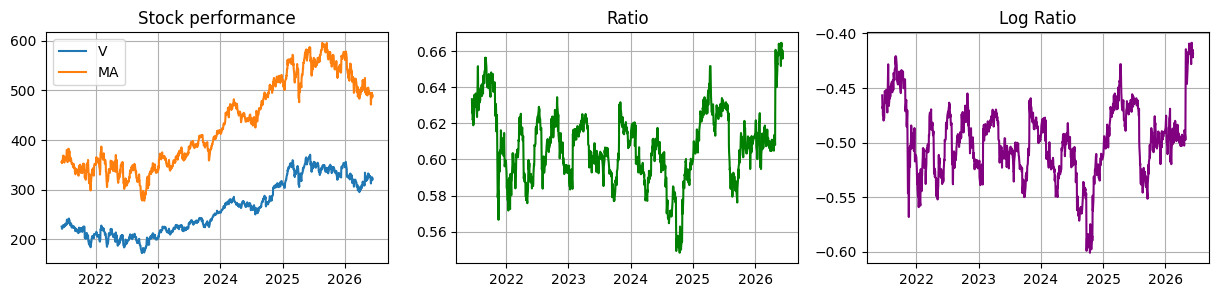

In [ ]:
# Charts to sense check
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
axs[0].plot(df[ticker1], label=ticker1)
axs[0].plot(df[ticker2], label=ticker2)
axs[0].set_title("Stock performance")
axs[0].legend()
axs[0].grid(True)


axs[1].plot(df.ratio, color="green")
axs[1].set_title("Ratio")
axs[1].grid(True)


axs[2].plot(df.log_ratio, color="purple")
axs[2].set_title("Log Ratio")
axs[2].grid(True)


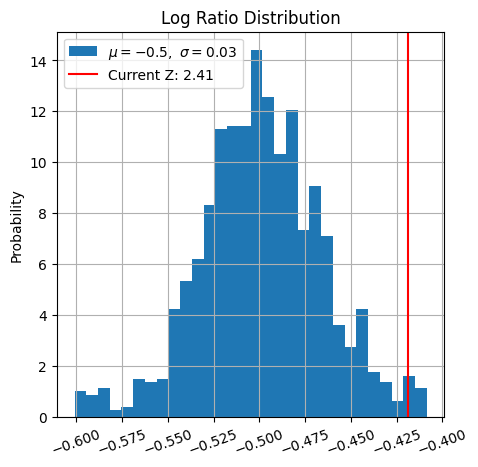

In [238]:
# Compute and chart Z score

ratio_mean = np.mean(df.log_ratio)
ratio_std = np.std(df.log_ratio)
z_score = (df.log_ratio.iloc[-1] - ratio_mean) / ratio_std

plt.subplots(1, 1, figsize=(5, 5))

plt.hist(df.log_ratio, 30, density=True, label=r"$\mu={},\ \sigma={}$".format(round(ratio_mean, 2), round(ratio_std, 2)))
plt.title("Log Ratio Distribution")
plt.ylabel("Probability")
plt.grid(True)
plt.xticks(rotation=20)
plt.axvline(df.log_ratio.iloc[-1], color="red", label=r"Current Z: {}".format(round(z_score, 2)))
plt.legend()
plt.show()
